# 06 - Time-Series Forecasting
ARIMA, SARIMA, and Prophet (with a statsmodels-based fallback when Prophet isn't installed) forecasts of daily average global temperature.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
%matplotlib inline


2026-07-03 05:39:07 | src.forecasting | WARNING | Prophet not installed - using statsmodels-based fallback forecaster instead.


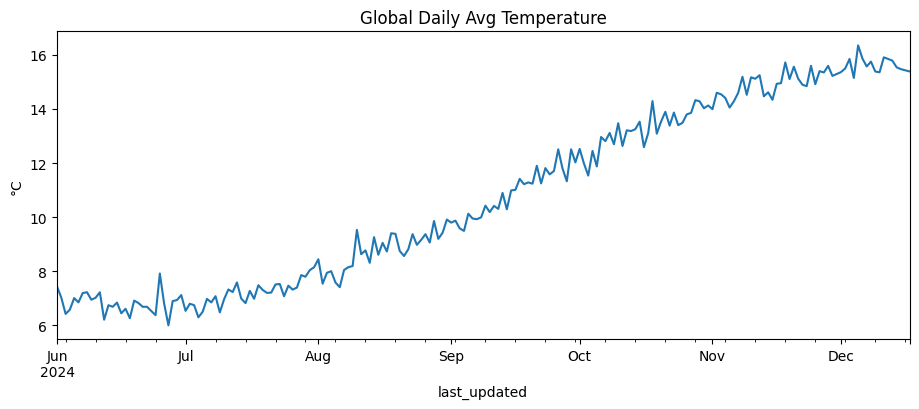

In [2]:
import pandas as pd
from src import config
from src.forecasting import (build_daily_series, forecast_arima, forecast_sarima,
                              forecast_prophet_or_fallback, evaluate_forecast)

df = pd.read_csv(config.CLEAN_DATA_FILE, parse_dates=[config.DATETIME_COL])
daily = build_daily_series(df)
daily.plot(figsize=(11,4), title='Global Daily Avg Temperature'); plt.ylabel('°C'); plt.show()

## ARIMA forecast

In [3]:
arima_mean, arima_ci, arima_model = forecast_arima(daily)
arima_mean

2024-12-18    15.692780
2024-12-19    15.705942
2024-12-20    15.707039
2024-12-21    15.707637
2024-12-22    15.708208
2024-12-23    15.708774
2024-12-24    15.709334
2024-12-25    15.709889
2024-12-26    15.710439
2024-12-27    15.710983
2024-12-28    15.711522
2024-12-29    15.712056
2024-12-30    15.712584
2024-12-31    15.713108
Freq: D, Name: predicted_mean, dtype: float64

## SARIMA forecast (weekly seasonality)

In [4]:
sarima_mean, sarima_ci, sarima_model = forecast_sarima(daily)
sarima_mean

2024-12-18    15.517415
2024-12-19    15.799158
2024-12-20    15.668095
2024-12-21    15.631191
2024-12-22    15.901477
2024-12-23    15.869728
2024-12-24    15.902804
2024-12-25    15.855606
2024-12-26    16.087523
2024-12-27    15.968455
2024-12-28    15.887831
2024-12-29    16.086909
2024-12-30    16.052895
2024-12-31    16.070216
Freq: D, Name: predicted_mean, dtype: float64

## Prophet / fallback forecast

In [5]:
prophet_fc = forecast_prophet_or_fallback(daily)
prophet_fc

2024-12-18    16.283950
2024-12-19    16.400678
2024-12-20    16.454147
2024-12-21    16.528119
2024-12-22    16.643820
2024-12-23    16.659246
2024-12-24    16.687544
2024-12-25    16.674610
2024-12-26    16.791338
2024-12-27    16.844807
2024-12-28    16.918778
2024-12-29    17.034479
2024-12-30    17.049906
2024-12-31    17.078204
Freq: D, Name: yhat, dtype: float64

## Visualize all three forecasts together

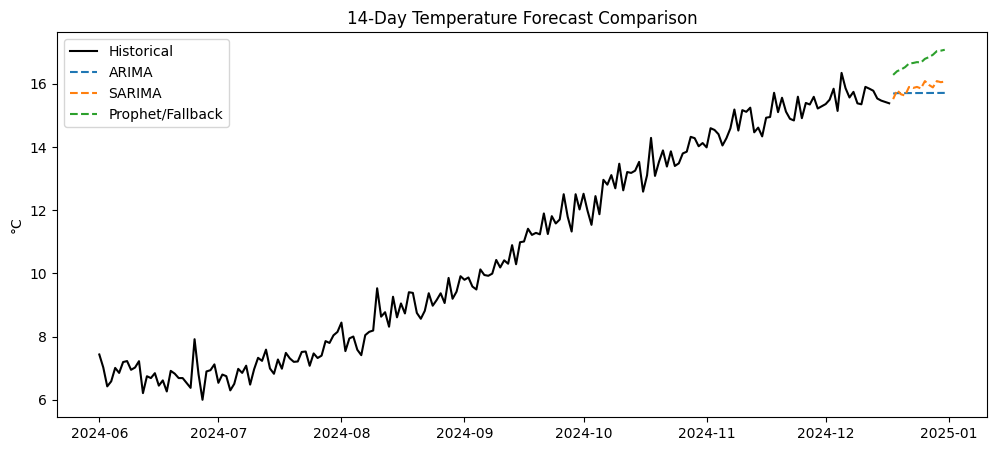

In [6]:
plt.figure(figsize=(12,5))
plt.plot(daily.index, daily.values, label='Historical', color='black')
plt.plot(arima_mean.index, arima_mean.values, label='ARIMA', linestyle='--')
plt.plot(sarima_mean.index, sarima_mean.values, label='SARIMA', linestyle='--')
plt.plot(prophet_fc.index, prophet_fc.values, label='Prophet/Fallback', linestyle='--')
plt.legend(); plt.title('14-Day Temperature Forecast Comparison'); plt.ylabel('°C'); plt.show()